In [8]:
import yfinance
import pandas as pd
import numpy as np
import ta
import matplotlib.pyplot as plt
import optuna


In [9]:
data_2 = yfinance.download("AAPL", start="2020-01-01", end="2025-01-01")

data = pd.DataFrame()
data['Close'] = data_2.Close
data['High'] = data_2.High
data['Low'] = data_2.Low
data['Open'] = data_2.Open

C:\Users\samue\AppData\Local\Temp\ipykernel_18340\3547496363.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_2 = yfinance.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [12]:
data_2

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267921,72.306491,70.568495,70.819193,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200
...,...,...,...,...,...
2024-12-24,256.797180,256.807105,253.902972,254.101897,23234700
2024-12-26,257.612701,258.686851,256.230269,256.787224,27237100


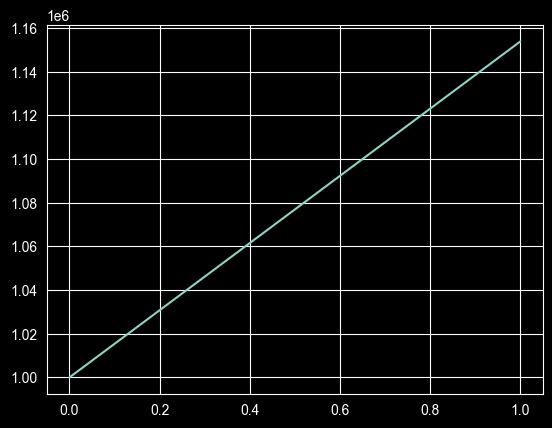

In [10]:
# constants
COM = 0.125 / 100
INITIAL_CASH = 1_000_000


def infer_periods_per_year(index: pd.DatetimeIndex) -> int:
    if len(index) < 2:
        return 252
    deltas = index.to_series().diff().dropna().dt.total_seconds()
    median_sec = deltas.median()
    if pd.isna(median_sec) or median_sec <= 0:
        return 252
    return int(round((365 * 24 * 3600) / median_sec))


def run_rsi_backtest(df: pd.DataFrame, params: dict, fee: float = COM, initial_cash: float = INITIAL_CASH):
    data_bt = df.copy()
    rsi_window = int(params["rsi_window"])
    data_bt["rsi"] = ta.momentum.RSIIndicator(data_bt["Close"], window=rsi_window).rsi()
    data_bt = data_bt.dropna().copy()

    cash = float(initial_cash)
    position = None
    equity_curve = []
    trade_pnls = []
    trade_returns = []

    for ts, row in data_bt.iterrows():
        price = float(row.Close)

        if position is not None:
            side = position["side"]
            qty = position["qty"]
            entry = position["entry"]
            notional = position["notional"]

            if side == "long":
                unrealized = (price - entry) * qty
                stop_hit = price <= position["sl_price"]
                tp_hit = price >= position["tp_price"]
                signal_exit = row.rsi > params["rsi_upper"]
            else:
                unrealized = (entry - price) * qty
                stop_hit = price >= position["sl_price"]
                tp_hit = price <= position["tp_price"]
                signal_exit = row.rsi < params["rsi_lower"]

            if stop_hit or tp_hit or signal_exit:
                exit_fee = price * qty * fee
                pnl = unrealized
                cash += notional + pnl - exit_fee
                trade_pnls.append(pnl - position["entry_fee"] - exit_fee)
                trade_returns.append((pnl - position["entry_fee"] - exit_fee) / notional)
                position = None

        long_signal = row.rsi < params["rsi_lower"]
        short_signal = row.rsi > params["rsi_upper"]

        if position is None and (long_signal or short_signal):
            qty = int(params["n_shares"])
            notional = price * qty
            entry_fee = notional * fee
            required_cash = notional + entry_fee

            if cash >= required_cash and qty > 0:
                cash -= required_cash
                side = "long" if long_signal else "short"
                sl_mult = (1 - params["sl"]) if side == "long" else (1 + params["sl"])
                tp_mult = (1 + params["tp"]) if side == "long" else (1 - params["tp"])

                position = {
                    "side": side,
                    "entry": price,
                    "qty": qty,
                    "notional": notional,
                    "entry_fee": entry_fee,
                    "sl_price": price * sl_mult,
                    "tp_price": price * tp_mult,
                }

        if position is None:
            equity = cash
        else:
            price_now = float(row.Close)
            if position["side"] == "long":
                unrealized = (price_now - position["entry"]) * position["qty"]
            else:
                unrealized = (position["entry"] - price_now) * position["qty"]
            equity = cash + position["notional"] + unrealized

        equity_curve.append((ts, equity))

    if position is not None:
        ts, row = data_bt.iloc[-1].name, data_bt.iloc[-1]
        price = float(row.Close)
        qty = position["qty"]
        if position["side"] == "long":
            pnl = (price - position["entry"]) * qty
        else:
            pnl = (position["entry"] - price) * qty
        exit_fee = price * qty * fee
        cash += position["notional"] + pnl - exit_fee
        trade_pnls.append(pnl - position["entry_fee"] - exit_fee)
        trade_returns.append((pnl - position["entry_fee"] - exit_fee) / position["notional"])
        equity_curve[-1] = (ts, cash)

    equity_df = pd.DataFrame(equity_curve, columns=["Datetime", "Equity"]).set_index("Datetime")
    return equity_df, np.array(trade_pnls), np.array(trade_returns)


def compute_metrics(equity_df: pd.DataFrame, trade_pnls: np.ndarray, trade_returns: np.ndarray):
    periods_per_year = infer_periods_per_year(equity_df.index)
    rets = equity_df["Equity"].pct_change().dropna()

    if rets.empty:
        return {
            "Sharpe": np.nan,
            "Sortino": np.nan,
            "Calmar": np.nan,
            "Max Drawdown": np.nan,
            "Win Rate": np.nan,
            "CAGR": np.nan,
        }

    mean_ret = rets.mean()
    std_ret = rets.std(ddof=0)
    downside = rets[rets < 0]
    downside_std = downside.std(ddof=0) if len(downside) > 0 else np.nan

    sharpe = (mean_ret / std_ret) * np.sqrt(periods_per_year) if std_ret > 0 else np.nan
    sortino = (mean_ret / downside_std) * np.sqrt(periods_per_year) if downside_std and downside_std > 0 else np.nan

    equity = equity_df["Equity"]
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    total_periods = len(rets)
    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (periods_per_year / total_periods) - 1 if total_periods > 0 else np.nan
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    win_rate = float((trade_pnls > 0).mean()) if len(trade_pnls) > 0 else np.nan

    return {
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Calmar": calmar,
        "Max Drawdown": max_dd,
        "Win Rate": win_rate,
        "CAGR": cagr,
    }


def returns_tables(equity_df: pd.DataFrame):
    eq = equity_df["Equity"]
    monthly = eq.resample("M").last().pct_change().dropna().to_frame("Monthly Return")
    quarterly = eq.resample("Q").last().pct_change().dropna().to_frame("Quarterly Return")
    annual = eq.resample("Y").last().pct_change().dropna().to_frame("Annual Return")
    return monthly, quarterly, annual


def objective(trial):
    params = {
        "rsi_window": trial.suggest_int("rsi_window", 5, 30),
        "rsi_lower": trial.suggest_int("rsi_lower", 15, 45),
        "rsi_upper": trial.suggest_int("rsi_upper", 55, 85),
        "n_shares": trial.suggest_int("n_shares", 50, 1200),
        "sl": trial.suggest_float("sl", 0.005, 0.10),
        "tp": trial.suggest_float("tp", 0.005, 0.20),
    }

    equity_df, trade_pnls, trade_returns = run_rsi_backtest(data, params, fee=COM)
    metrics = compute_metrics(equity_df, trade_pnls, trade_returns)
    calmar = metrics["Calmar"]
    if np.isnan(calmar) or np.isinf(calmar):
        return -1e6
    return calmar


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=120, show_progress_bar=False)

best_params = study.best_params
print("Best params:", best_params)
print("Best Calmar (train):", study.best_value)

best_equity, best_trade_pnls, best_trade_returns = run_rsi_backtest(data, best_params, fee=COM)
best_metrics = compute_metrics(best_equity, best_trade_pnls, best_trade_returns)

metrics_df = pd.DataFrame([best_metrics]).T
metrics_df.columns = ["Value"]
print("\nPerformance metrics:")
display(metrics_df)

monthly_tbl, quarterly_tbl, annual_tbl = returns_tables(best_equity)
print("\nMonthly returns:")
display(monthly_tbl.tail(12))
print("\nQuarterly returns:")
display(quarterly_tbl)
print("\nAnnual returns:")
display(annual_tbl)

plt.figure(figsize=(12, 4))
plt.plot(best_equity.index, best_equity["Equity"], label="Portfolio Value")
plt.title("Portfolio value through time")
plt.xlabel("Datetime")
plt.ylabel("Equity")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Robustness analysis: parameter sensitivity (+/-20%)
base = best_params.copy()
sensitivity_rows = []
for key in ["rsi_window", "rsi_lower", "rsi_upper", "n_shares", "sl", "tp"]:
    for factor in [0.8, 1.2]:
        p = base.copy()
        if key in ["rsi_window", "rsi_lower", "rsi_upper", "n_shares"]:
            p[key] = max(1, int(round(base[key] * factor)))
        else:
            p[key] = max(0.0005, float(base[key] * factor))

        if p["rsi_lower"] >= p["rsi_upper"]:
            continue

        eq, pnl, tr = run_rsi_backtest(data, p, fee=COM)
        m = compute_metrics(eq, pnl, tr)
        sensitivity_rows.append({
            "parameter": key,
            "factor": factor,
            "value": p[key],
            "Calmar": m["Calmar"],
            "Sharpe": m["Sharpe"],
            "Sortino": m["Sortino"],
            "Max Drawdown": m["Max Drawdown"],
            "Win Rate": m["Win Rate"],
        })

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(["parameter", "factor"])
print("\nSensitivity analysis (+/-20%):")
display(sensitivity_df)

# Transaction costs impact
cost_rows = []
for fee in [0.0, COM]:
    eq, pnl, tr = run_rsi_backtest(data, best_params, fee=fee)
    m = compute_metrics(eq, pnl, tr)
    m["fee"] = fee
    cost_rows.append(m)

cost_df = pd.DataFrame(cost_rows)[["fee", "Calmar", "Sharpe", "Sortino", "Max Drawdown", "Win Rate", "CAGR"]]
print("\nTransaction cost impact:")
display(cost_df)
